In [1]:
import jax, jax.numpy as jnp
from flax import nnx
jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64

from jaxpi.ssbroyden_optax import scale_by_ssbroyden_wolfe_oracle

In [2]:
def lobatto_nodes_weights(N):
    j = jnp.arange(N+1, dtype=jnp.float64)
    x = jnp.cos(jnp.pi * j / N)
    w = jnp.where((j==0) | (j==N), 0.5, 1.0) * ((-1.0) ** j)  # classic weights
    return x, w  # (N+1,), (N+1,)

def barycentric_eval(x, nodes, w, y, tol=1e-15):
    # x: (B,); nodes,w,y: (M,)
    # If x hits a node, return that value exactly
    def eval_one(xi):
        d = xi - nodes
        k = jnp.argmin(jnp.abs(d))
        return jnp.where(jnp.abs(d[k]) < tol, y[k],
                         (jnp.sum((w / d) * y) / jnp.sum(w / d)))
    return jax.vmap(eval_one)(x)

class BarycentricHead(nnx.Module):
    nodes: jnp.ndarray
    w: nnx.Param #jnp.ndarray
    y: nnx.Param  # trainable nodal values (or set from data and freeze)

    def __init__(self, nodes, w, y_init=None, *, rngs: nnx.Rngs = nnx.Rngs(0)):
        self.nodes = nodes
        self.w = nnx.Param(jnp.asarray(w, dtype=jnp.float64))
        if y_init is None:
            y_init = jnp.zeros_like(nodes)
        self.y = nnx.Param(y_init).reshape(-1)

    def __call__(self, x):
        # x: (B,) or (B,1)
        x = x.ravel()
        return barycentric_eval(x, self.nodes, self.w, self.y).reshape(-1, 1)


In [3]:

# Example: exact interpolant for f at Lobatto nodes
N = 64
nodes, w = lobatto_nodes_weights(N)
f = lambda x: jnp.sin(8.0 * x).reshape(-1, 1)
y_data = f(nodes)
head = BarycentricHead(nodes, w, y_init=y_data)   # exact interpolant
# head(x_batch) now evaluates the Chebyshev–Lobatto barycentric interpolant

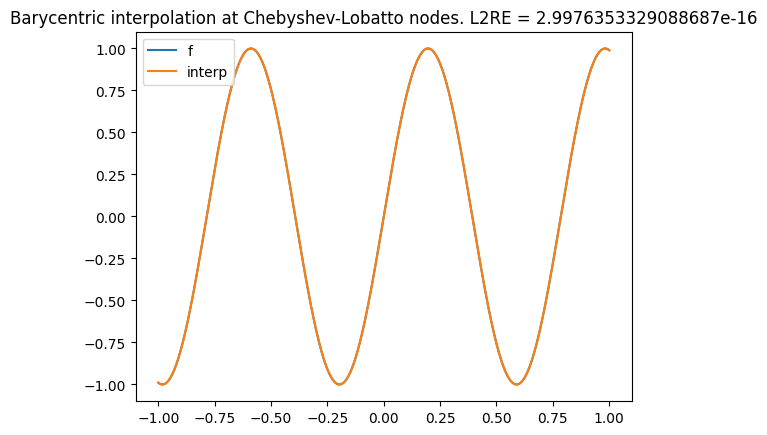

In [4]:
x = jnp.linspace(-1, 1, 2001)
y = head(x)
import matplotlib.pyplot as plt
plt.plot(x, f(x), label="f")
plt.plot(x, y, label="interp")
plt.title(f"Barycentric interpolation at Chebyshev-Lobatto nodes. L2RE = {jnp.linalg.norm(y-f(x))/jnp.linalg.norm(f(x))}")
plt.legend()
plt.show()

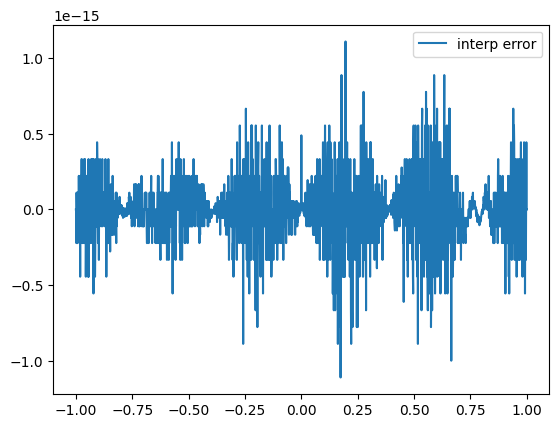

In [5]:
plt.plot(x, y - f(x), label="interp error")
plt.legend()
plt.show()

In [6]:
# Training functions
def loss_fn(model, x: jnp.ndarray, y: jnp.ndarray):
    y_hat = model(x)
    return jnp.mean((y_hat - y) ** 2)

def rel_l2_error(model, x_eval, y_eval):
    y_hat = model(x_eval)
    return jnp.linalg.norm(y_hat - y_eval) / jnp.linalg.norm(y_eval)

@nnx.jit
def train_step(model, optimizer: nnx.Optimizer, x: jnp.ndarray, y: jnp.ndarray):
    loss, grads = nnx.value_and_grad(loss_fn)(model, x, y)
    optimizer = optimizer.update(model, grads)
    return loss

def f_sin(x: jnp.ndarray, k: int) -> jnp.ndarray:
    return jnp.sin(2.0 * DTYPE(k) * jnp.pi * x)

In [7]:
def run_experiment_broyden(
    M: int = 33,
    k: int = 3,
    # training
    steps: int = 50000, 
    n_train: int = 4097,
    n_eval: int = 10000,
    *,
    separate_weights: bool = False,
    rng: nnx.Rngs = nnx.Rngs(0),

):
    
    # training grid
    x_train = jnp.linspace(-1.0, 1.0, n_train, dtype=DTYPE).reshape(-1, 1)
    y_train = f_sin(x_train, k).reshape(-1, 1)

    x_eval = jnp.linspace(-1.0, 1.0, n_eval, dtype=DTYPE).reshape(-1, 1)
    y_eval = f_sin(x_eval, k).reshape(-1, 1)

    nodes, w = lobatto_nodes_weights(M)
    y_data = f_sin(nodes, k)
    model = BarycentricHead(nodes, w, y_init=y_data)

    init_graphdef, init_state = nnx.split(model)
    init_model = nnx.merge(init_graphdef, init_state)

    # Create the optimizer pipeline
    # Build an (f,g) oracle that accepts a PARAMS-like pytree.
    # It reconstructs a temporary model using a static GraphDef.
    def make_fg_oracle(graphdef, base_state):
        """Oracle f(params, x, y) that rebuilds the model and stamps in `params` arrays."""
        base_state_pure = nnx.freeze(nnx.pure(base_state))  # pure arrays FlatState

        def f(params, x, y):
            # 1) reconstruct Node from the static graph + base state
            node = nnx.merge(graphdef, base_state_pure)
            # 2) stamp the param arrays into the live Node (structure must match nnx.Param tree)
            nnx.update(node, params)
            # 3) compute loss
            return loss_fn(node, x, y)

        return nnx.jit(nnx.value_and_grad(f, argnums=0))

    tx = scale_by_ssbroyden_wolfe_oracle(lr=1.0, c1=1e-4, c2=0.9, max_ls=20)

    # Wrap with the NNX optimizer (wrt=nnx.Param is required in 0.11)
    optim = nnx.Optimizer(model, tx, wrt=nnx.Param)  # kwargs will be forwarded to tx.update(...) :contentReference[oaicite:2]{index=2}

    # Build the oracle once from a static graphdef
    graphdef, base_state = nnx.split(model)                 # base_state is the full FlatState (Params + Variables)
    base_state = nnx.freeze(nnx.pure(base_state))           # make it a pure arrays pytree for JIT-friendliness
    fg_oracle = make_fg_oracle(graphdef, base_state)

    @nnx.jit
    def train_step_b(model, opt, x, y):
        # grads w.r.t. model Params
        def cur_loss(m): return loss_fn(m, x, y)
        f_k, grads = nnx.value_and_grad(cur_loss, argnums=nnx.DiffState(0, nnx.Param))(model)

        # Pass oracle + runtime tensors via **kwargs (forwarded to tx.update)
        opt.update(model, grads, f_k=f_k, fg_oracle=fg_oracle, loss_args=(x, y))
        return f_k

    # training loop
    pbar = tqdm(range(steps), desc="training")
    print("Initial eval rel L2:", rel_l2_error(model, x_eval, y_eval))
    for i in pbar:
        loss = train_step_b(model, optim, x_train, y_train)
        if i % 10 == 0:
            eval_error = rel_l2_error(model, x_eval, y_eval)
            pbar.set_description(f"step {i}, train loss={loss:.3e}, eval rel L2={eval_error:.3e}")
    
    return model, init_model